In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [3]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.dropout1,
            self.conv2, self.chomp2, self.relu2, self.dropout2
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNForecaster(nn.Module):
    def __init__(self, input_size, channels=[32, 64], kernel_size=3, dropout=0.2, output_size=5):
        super().__init__()

        layers = []
        in_channels = input_size

        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout
                )
            )
            in_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], output_size)

    def forward(self, x):
        x = x.transpose(1, 2)
        y = self.tcn(x)
        y = y[:, :, -1]
        y = self.fc(y)
        return y

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TCNForecaster(
    input_size=5,
    channels=[32, 64],
    kernel_size=3,
    dropout=0.2,
    output_size=5
).to(device)

model.load_state_dict(torch.load("models/dataset1/tcn_dataset1_forecaster.pt", map_location=device))
model.eval()

with open("models/dataset1/scaler_dataset1.pkl", "rb") as f:
    scaler = pickle.load(f)

print("Model and scaler loaded successfully.")

Model and scaler loaded successfully.


In [5]:
files = [
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\carton_1.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\carton_2.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\clothing_1.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\clothing_2.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\electrical_1.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\electrical_2.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\electrical_3.csv",
"D:\Master Of Data Science And AI\Capstone\model\data\dataset1\electrical_4.csv"
]

dfs = []
for f in files:
    temp = pd.read_csv(f)
    temp["scenario"] = os.path.basename(f)
    dfs.append(temp)

df_all = pd.concat(dfs, ignore_index=True)
print(df_all.shape)
df_all.head()

(11797, 19)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Yasitha\AppData\Local\Temp\ipykernel_15544\2948524488.py:2: SyntaxWarning: invalid escape sequence '\M'
  "D:\Master Of Data Science And AI\Capstone\model\data\dataset1\carton_1.csv",
C:\User

,Time,Reading ID,Humidity,Temperature,MQ139,TVOC,eCO2,Detector,Status,scenario,Reading ID#,Humidity%,Humidity,Temperature,MQ139,TVOC,eCO2,Detector,Temperature
0,0:00:00,1.0,43.5,21.3,98.0,0.0,400.0,OFF,0,carton_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0:00:01,2.0,43.5,21.3,97.0,0.0,400.0,OFF,0,carton_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0:00:02,3.0,43.6,21.4,97.0,0.0,400.0,OFF,0,carton_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0:00:03,4.0,43.6,21.4,97.0,0.0,400.0,OFF,0,carton_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0:00:04,5.0,43.7,21.4,98.0,0.0,400.0,OFF,0,carton_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
features = ["Temperature", "Humidity", "TVOC", "eCO2", "MQ139"]

df_model = df_all[features + ["Status", "scenario"]].copy()

for col in features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model[features] = df_model[features].ffill().bfill()

print(df_model[features].isna().sum())

Temperature    0
Humidity       0
TVOC           0
eCO2           0
MQ139          0
dtype: int64


In [7]:
X_full = scaler.transform(df_model[features])
print(X_full.shape)

(11797, 5)


In [8]:
window_size = 60

X_full_windows = []
y_full_windows = []
status_full = []
scenario_full = []

for i in range(len(X_full) - window_size):
    X_full_windows.append(X_full[i:i+window_size])
    y_full_windows.append(X_full[i+window_size])
    status_full.append(df_model["Status"].iloc[i+window_size])
    scenario_full.append(df_model["scenario"].iloc[i+window_size])

X_full_windows = np.array(X_full_windows, dtype=np.float32)
y_full_windows = np.array(y_full_windows, dtype=np.float32)
status_full = np.array(status_full)
scenario_full = np.array(scenario_full)

print(X_full_windows.shape, y_full_windows.shape, status_full.shape)

(11737, 60, 5) (11737, 5) (11737,)


In [9]:
with torch.no_grad():
    X_test = torch.tensor(X_full_windows, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_full_windows, dtype=torch.float32).to(device)
    y_hat = model(X_test)

full_residuals = torch.abs(y_hat - y_test).cpu().numpy()
full_residual_score = full_residuals.mean(axis=1)

print(full_residual_score.shape)

(11737,)


In [10]:
df_result = pd.DataFrame({
    "ResidualScore": full_residual_score,
    "Status": status_full,
    "Scenario": scenario_full
})

df_result.head()

,ResidualScore,Status,Scenario
0,0.210373,1,carton_1.csv
1,0.206374,1,carton_1.csv
2,0.215335,1,carton_1.csv
3,0.216920,1,carton_1.csv
4,0.222898,1,carton_1.csv


In [11]:
risk = (full_residual_score - full_residual_score.min()) / (
    full_residual_score.max() - full_residual_score.min()
)

df_result["Risk"] = risk
df_result.head()

,ResidualScore,Status,Scenario,Risk
0,0.210373,1,carton_1.csv,0.035063
1,0.206374,1,carton_1.csv,0.034390
2,0.215335,1,carton_1.csv,0.035899
3,0.216920,1,carton_1.csv,0.036166
4,0.222898,1,carton_1.csv,0.037172


In [12]:
print("Mean Residual by Status")
print(df_result.groupby("Status")["ResidualScore"].mean())

print("\nMedian Residual by Status")
print(df_result.groupby("Status")["ResidualScore"].median())

print("\nMean Risk by Status")
print(df_result.groupby("Status")["Risk"].mean())

Mean Residual by Status
Status
0    0.024609
1    0.250968
2    0.588596
Name: ResidualScore, dtype: float32

Median Residual by Status
Status
0    0.009544
1    0.099124
2    0.753719
Name: ResidualScore, dtype: float32

Mean Risk by Status
Status
0    0.003784
1    0.041899
2    0.098749
Name: Risk, dtype: float32


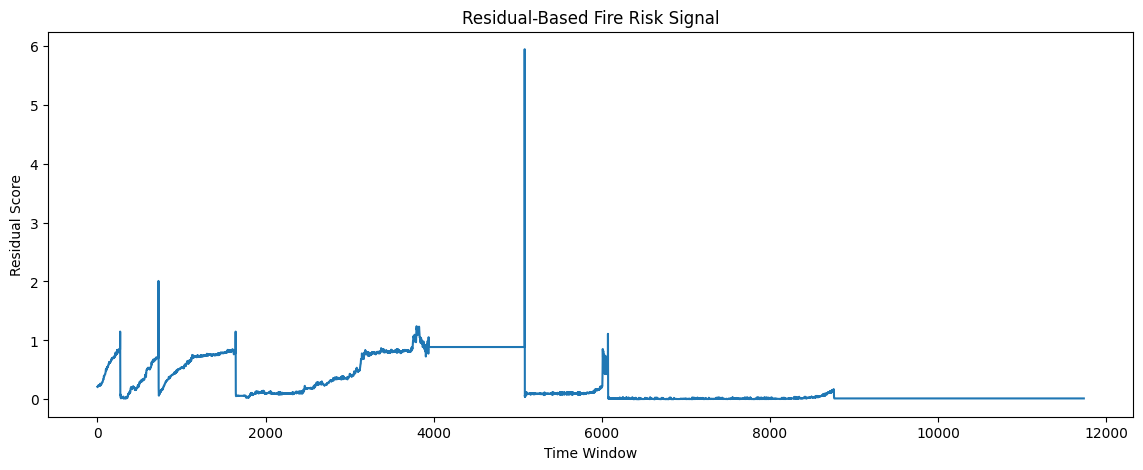

In [13]:
plt.figure(figsize=(14,5))
plt.plot(df_result["ResidualScore"].values)
plt.title("Residual-Based Fire Risk Signal")
plt.xlabel("Time Window")
plt.ylabel("Residual Score")
plt.show()

C:\Users\Yasitha\AppData\Local\Temp\ipykernel_15544\3229607185.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Normal (0)", "Pre-Alarm (1)", "Alarm (2)"])


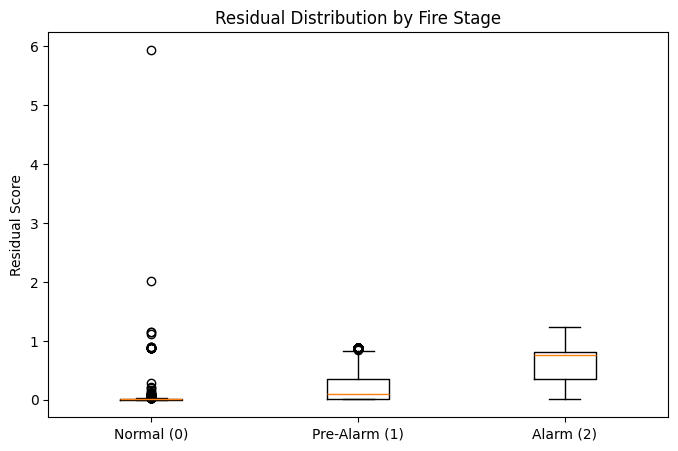

In [14]:
data = [
    df_result[df_result["Status"] == 0]["ResidualScore"],
    df_result[df_result["Status"] == 1]["ResidualScore"],
    df_result[df_result["Status"] == 2]["ResidualScore"]
]

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=["Normal (0)", "Pre-Alarm (1)", "Alarm (2)"])
plt.ylabel("Residual Score")
plt.title("Residual Distribution by Fire Stage")
plt.show()

In [15]:
os.makedirs("results", exist_ok=True)
df_result.to_csv("results/results_dataset1_analysis.csv", index=False)
print("Dataset 1 analysis results saved.")

Dataset 1 analysis results saved.


In [16]:
print("Mean Residual by Scenario and Status")
print(df_result.groupby(["Scenario", "Status"])["ResidualScore"].mean())

Mean Residual by Scenario and Status
Scenario          Status
carton_1.csv      1         0.422000
                  2         0.768850
carton_2.csv      0         0.041070
                  1         0.340243
                  2         0.695428
clothing_1.csv    0         0.258590
                  1         0.444565
                  2         0.766938
clothing_2.csv    0         0.069237
                  1         0.153282
                  2         0.724839
electrical_1.csv  0         0.888561
                  1         0.887876
                  2         0.887876
electrical_2.csv  0         0.500005
                  1         0.135455
                  2         0.550055
electrical_3.csv  0         0.010685
                  1         0.049883
                  2         0.138583
electrical_4.csv  0         0.015846
                  1         0.015655
                  2         0.015655
Name: ResidualScore, dtype: float32


In [17]:
print("Mean Risk by Scenario and Status")
print(df_result.groupby(["Scenario", "Status"])["Risk"].mean())

Mean Risk by Scenario and Status
Scenario          Status
carton_1.csv      1         0.070697
                  2         0.129101
carton_2.csv      0         0.006555
                  1         0.056931
                  2         0.116738
clothing_1.csv    0         0.043182
                  1         0.074497
                  2         0.128779
clothing_2.csv    0         0.011298
                  1         0.025450
                  2         0.121690
electrical_1.csv  0         0.149258
                  1         0.149143
                  2         0.149143
electrical_2.csv  0         0.083832
                  1         0.022448
                  2         0.092260
electrical_3.csv  0         0.001439
                  1         0.008039
                  2         0.022975
electrical_4.csv  0         0.002308
                  1         0.002276
                  2         0.002276
Name: Risk, dtype: float32


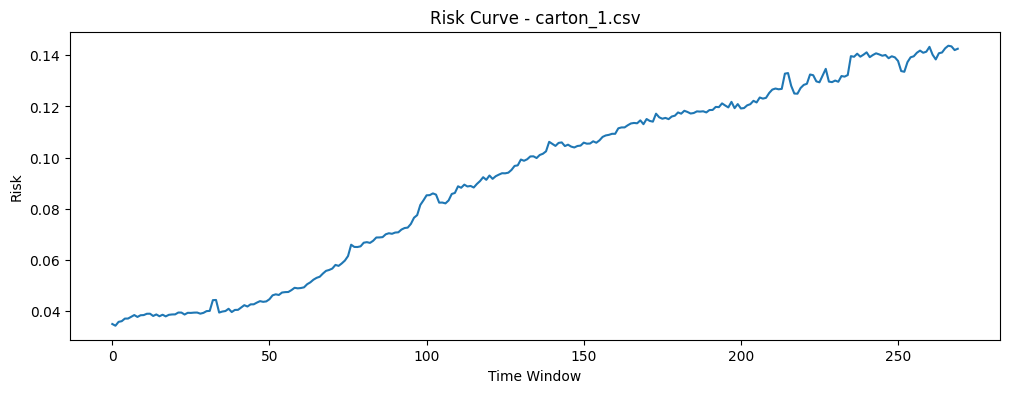

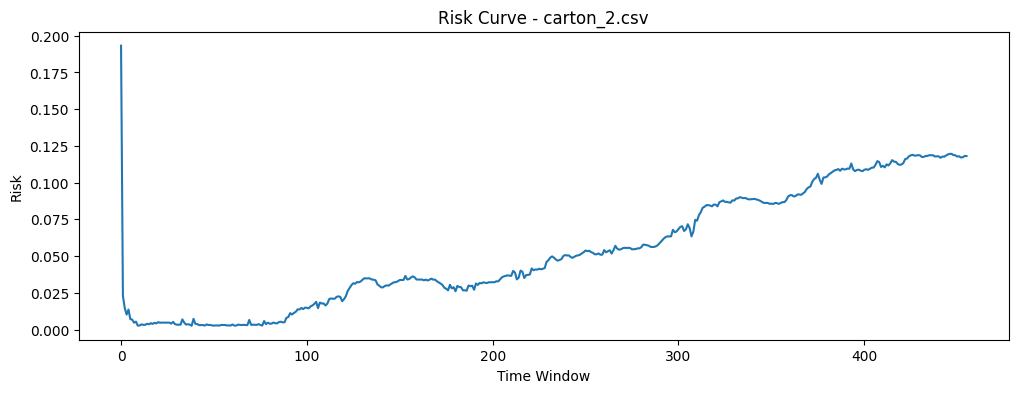

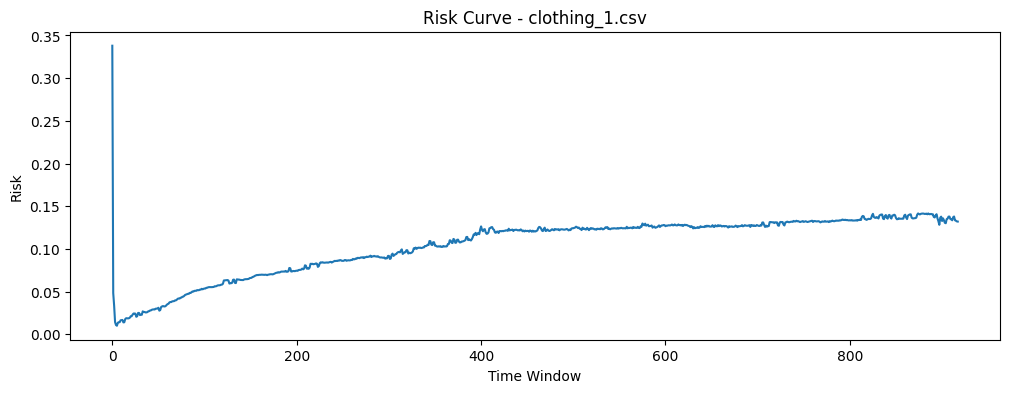

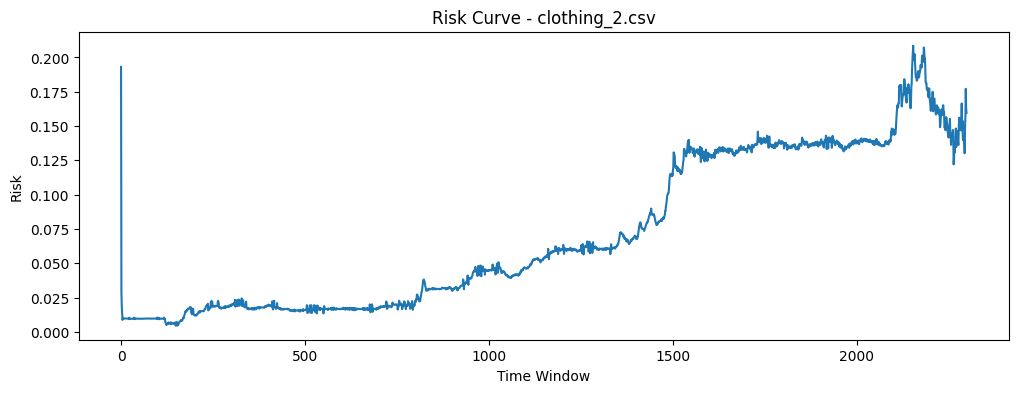

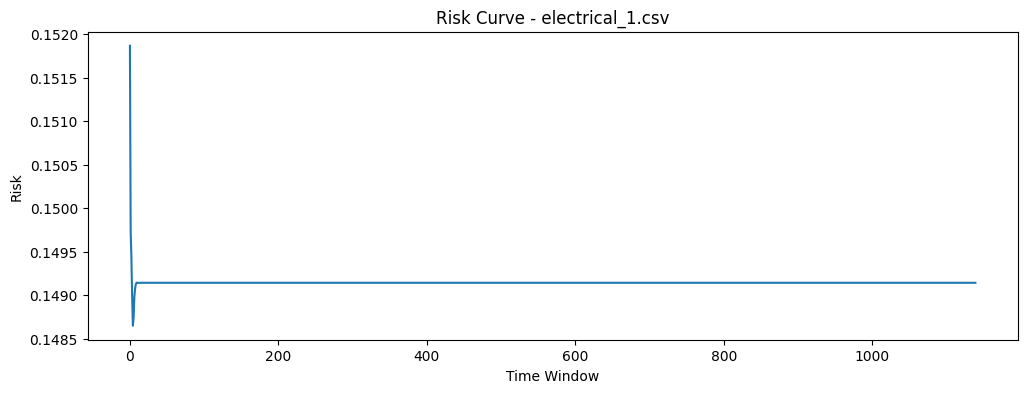

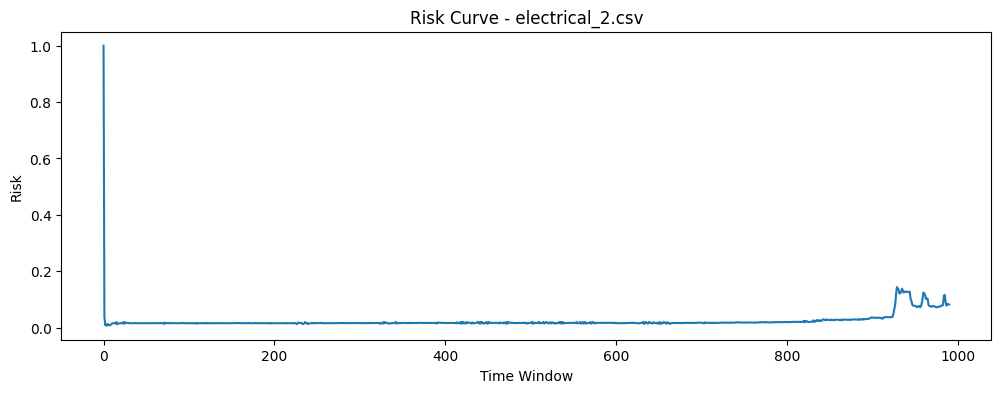

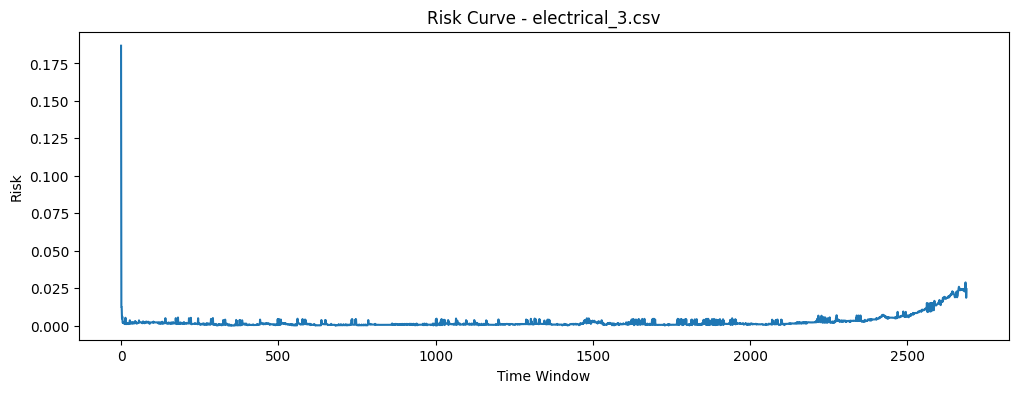

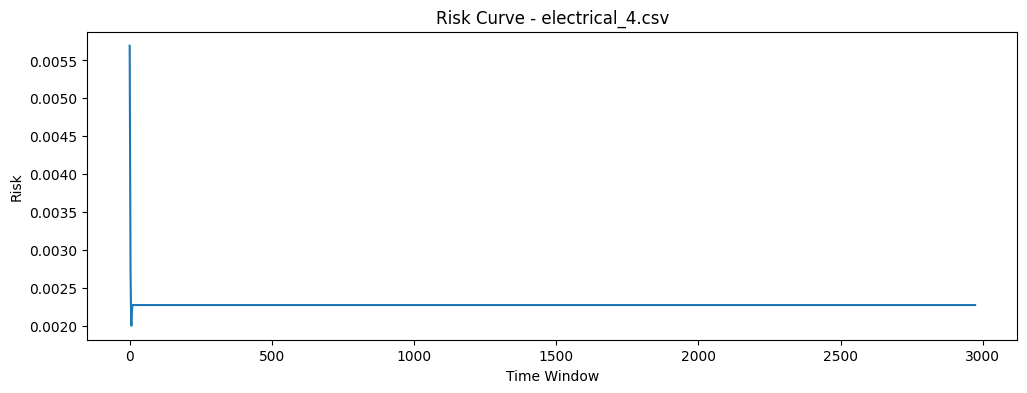

In [18]:
scenarios = df_result["Scenario"].unique()

for sc in scenarios:
    temp = df_result[df_result["Scenario"] == sc]
    
    plt.figure(figsize=(12,4))
    plt.plot(temp["Risk"].values)
    plt.title(f"Risk Curve - {sc}")
    plt.xlabel("Time Window")
    plt.ylabel("Risk")
    plt.show()

In [22]:
import pandas as pd

df_test_result = pd.read_csv("results/dataset1_test_results_with_alarm.csv")

print(df_test_result.head())

   residual  risk_tcn  iso_score      ae_score  drift_strength  drift_flag  \
0  0.418966  0.208810   1.000000  4.004398e-03      140.763282           0   
1  0.125625  0.062015   0.998088  1.413410e-04        0.000000           0   
2  0.125625  0.062015   0.998088  1.413410e-04     2221.155825           1   
3  0.009862  0.004084   0.209325  6.547090e-07        1.349182           0   
4  1.078830  0.539023   1.000000  2.312014e-02        0.000000           0   

   TrueLabel  PredLabel  FinalRisk  PersistFlag  DriftFlag  FinalAlarm  
0          1          1   0.502558            0          0           0  
1          1          1   0.582500            0          0           0  
2          0          0   0.101945            0          1           0  
3          0          0   0.100233            0          0           0  
4          1          1   0.513375            0          0           0  


In [29]:
import numpy as np

def persistence_filter(risk, threshold=0.5, min_len=3):
    out = np.zeros(len(risk), dtype=int)
    count = 0
    for i, r in enumerate(risk):
        if r >= threshold:
            count += 1
        else:
            count = 0
        if count >= min_len:
            out[i] = 1
    return out

df_test_result = df_test_result.sort_index()

df_test_result["PersistFlag"] = persistence_filter(
    df_test_result["FinalRisk"].values,
    threshold=0.5,
    min_len=3
)

In [30]:
df_test_result["FinalAlarm"] = (
    (df_test_result["PersistFlag"] == 1) &
    (df_test_result["DriftFlag"] == 0)
).astype(int)

In [31]:
print(df_test_result["FinalAlarm"].value_counts())

FinalAlarm
0    1634
1     714
Name: count, dtype: int64


In [32]:
from sklearn.metrics import classification_report

true_alarm = (df_test_result["TrueLabel"] >= 1).astype(int)
pred_alarm = df_test_result["FinalAlarm"]

print(classification_report(true_alarm, pred_alarm))

              precision    recall  f1-score   support

           0       0.34      1.00      0.51       556
           1       1.00      0.40      0.57      1792

    accuracy                           0.54      2348
   macro avg       0.67      0.70      0.54      2348
weighted avg       0.84      0.54      0.56      2348



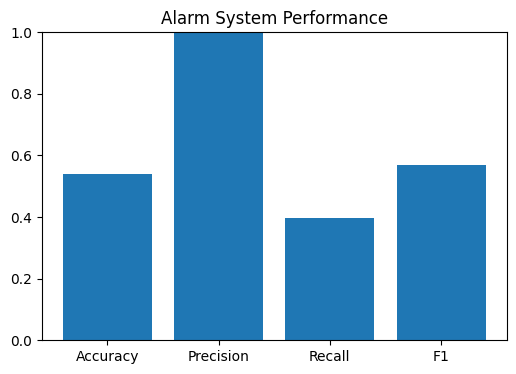

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [
    accuracy_score(true_alarm, pred_alarm),
    precision_score(true_alarm, pred_alarm),
    recall_score(true_alarm, pred_alarm),
    f1_score(true_alarm, pred_alarm)
]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylim(0,1)
plt.title("Alarm System Performance")
plt.show()

In [35]:
print(df_test_result["FinalAlarm"].value_counts())

FinalAlarm
0    1634
1     714
Name: count, dtype: int64
